# Código Original

In [1]:
import numpy as np
import mglearn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [2]:
#load extended boston dataset
X,y = mglearn.datasets.load_extended_boston()
print("X.shape: {}".format(X.shape))

X.shape: (506, 104)


# Exercícios

## 2.

Faça uma divisão treino/teste com os valores por omissão (treino=75%, teste=25%).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

## 3.

Construa um modelo com o algoritmo de Regressão Linear e calcule o desempenho sobre ambos os
conjuntos.

In [4]:
#criar modelo
linreg = LinearRegression()

In [5]:
#treinar modelo
linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
#calcular R^2 no treino e no teste
r2_train = linreg.score(X_train, y_train)
r2_test = linreg.score(X_test, y_test)

print(f"LinearRegression: R^2 train={r2_train:.3f}, test={r2_test:.3f}")

LinearRegression: R^2 train=0.952, test=0.607


## 4.

Construa 3 modelos com o algoritmo de Regressão Ridge e calcule o desempenho sobre ambos os
conjuntos para valores de alfa={0.1, 1, 10}.

In [7]:
alfa = [0.1, 1, 10]
ridge = []
r2_train = []
r2_test = []

for a in alfa:
    #criar modelo Ridge
    model = Ridge(alpha=a, random_state=0)
    #treinar modelo Ridge
    model.fit(X_train, y_train)
    
    #calcular R^2
    r2_train.append(model.score(X_train, y_train))
    r2_test.append(model.score(X_test, y_test))
    
    #guardar modelo
    ridge.append(model)
    
df = pd.DataFrame({
    "Alfa": list(alfa),
    "R^2 do treino": r2_train,
    "R^2 do teste": r2_test
    })
print(df.to_string(index=False))  

 Alfa  R^2 do treino  R^2 do teste
  0.1       0.928227      0.772207
  1.0       0.885797      0.752768
 10.0       0.788279      0.635941


## 5.

Utilizando a biblioteca "matplotlib" faça um gráfico com a magnitude dos coeficientes dos 4
modelos construídos. Os coeficientes são guardados no atributo "coef_" do modelo.

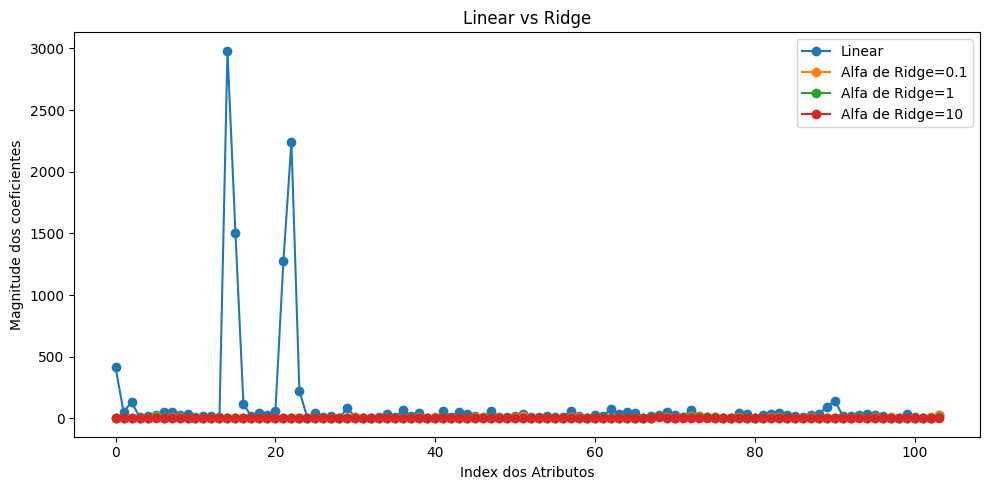

In [8]:
plt.figure(figsize=(10, 5))
coefs_linreg = linreg.coef_
coefs_ridge = [r.coef_ for r in ridge]

plt.plot(np.abs(coefs_linreg), marker="o", label="Linear")
for a, c in zip(alfa, coefs_ridge):
    plt.plot(np.abs(c), marker="o", label=f"Alfa de Ridge={a}")
    
plt.xlabel("Index dos Atributos")
plt.ylabel("Magnitude dos coeficientes")
plt.title("Linear vs Ridge")
plt.legend()
plt.tight_layout()
plt.show()

## 6.

Desenhe a curva de aprendizagem dos algoritmos de regressão Linear e regressão Ridge (alfa=1).
Considere diferentes tamanhos do conj de treino (por exemplo {50, 100, …}.

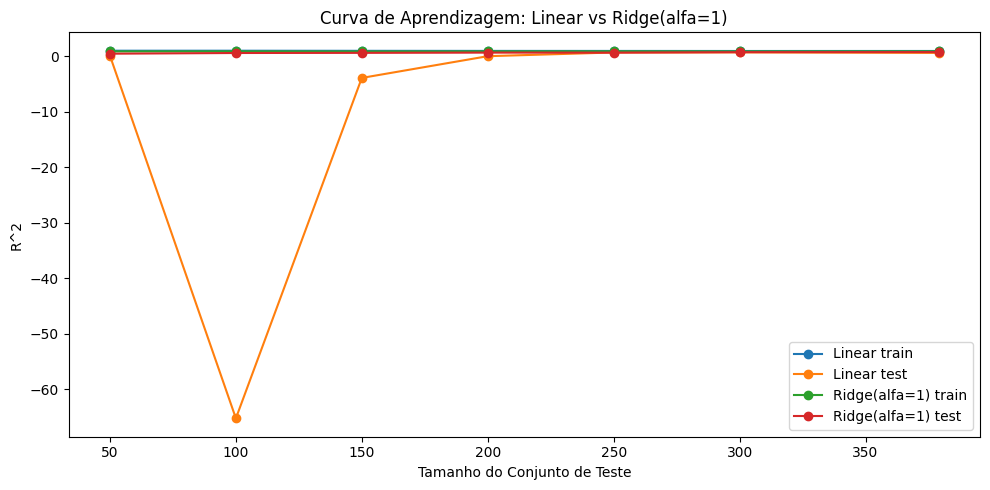

In [9]:
treinos = [50, 100, 150, 200, 250, 300, len(X_train)]
linreg_train_scores, linreg_test_scores = [], []
ridge_train_scores, ridge_test_scores = [], []

for n in treinos:
    #sub amostras
    X_sub = X_train[:n]
    y_sub = y_train[:n]
    #cria e treina modelo LinearRegression
    linreg = LinearRegression().fit(X_sub, y_sub)
    #métricas
    linreg_train_scores.append(linreg.score(X_sub, y_sub))
    linreg_test_scores.append(linreg.score(X_test, y_test))
    
    #cria e treina modelo Ridge
    ridge = Ridge(alpha=1, random_state=0).fit(X_sub, y_sub)
    #métricas
    ridge_train_scores.append(ridge.score(X_sub, y_sub))
    ridge_test_scores.append(ridge.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(treinos, linreg_train_scores, "-o", label="Linear train")
plt.plot(treinos, linreg_test_scores, "-o", label="Linear test")
plt.plot(treinos, ridge_train_scores, "-o", label="Ridge(alfa=1) train")
plt.plot(treinos, ridge_test_scores, "-o", label="Ridge(alfa=1) test")
plt.xlabel("Tamanho do Conjunto de Teste")
plt.ylabel("R^2")
plt.title("Curva de Aprendizagem: Linear vs Ridge(alfa=1)")
plt.legend()
plt.tight_layout()
plt.show()

## 7.

Construa 3 modelos com o algoritmo de Regressão Lasso e calcule o desempenho sobre ambos os
conjuntos para valores de alfa={1, 0.01, 0.0001}. Para além do cálculo do desempenho sobre o conj
de treino e teste, indique o nº de atributos com coeficientes distintos de zero.

In [10]:
alfa = [1, 0.01, 0.0001]
lasso_models = []
r2_train = []
r2_test = []

for a in alfa:
    #criar modelo Lasso
    lasso = Lasso(alpha=a, max_iter=100000, random_state=0)
    #treinar modelo Lasso
    lasso.fit(X_train, y_train)
    #métricas
    r2_train.append(lasso.score(X_train, y_train))
    r2_test.append(lasso.score(X_test, y_test))
    non_zero = np.sum(lasso.coef_ != 0)

    lasso_models.append(lasso)

df = pd.DataFrame({
    "Alfa": list(alfa),
    "R^2 do treino": r2_train,
    "R^2 do teste": r2_test
    })
print(df.to_string(index=False))

  Alfa  R^2 do treino  R^2 do teste
1.0000       0.293238      0.209375
0.0100       0.896223      0.765657
0.0001       0.950716      0.643747


## 8.

Faça um gráfico com a magnitude dos coeficientes dos 3 modelos Lasso construídos e o modelo
Ridge com alfa=0.1

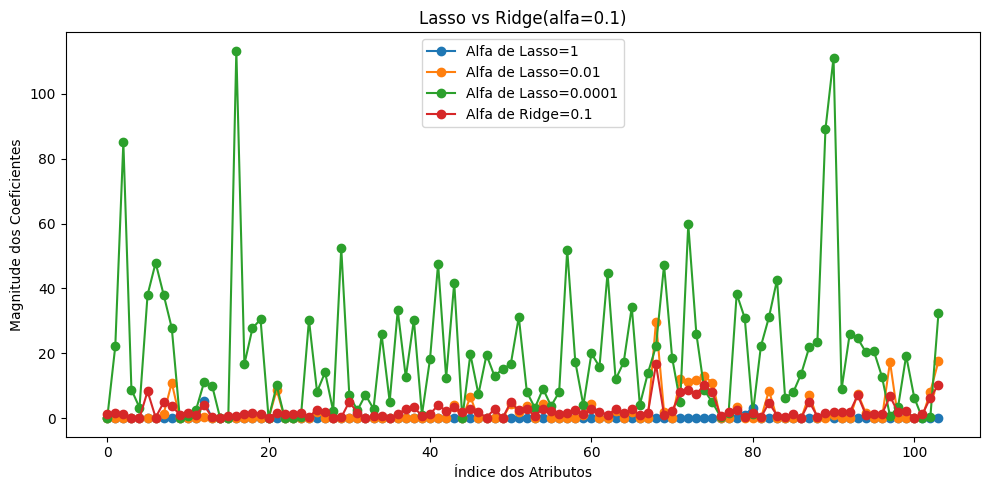

In [11]:
plt.figure(figsize=(10, 5))

for a, m in zip(alfa, lasso_models):
    plt.plot(np.abs(m.coef_), marker="o", label=f"Alfa de Lasso={a}")
    
plt.plot(np.abs(ridge.coef_), marker="o", label="Alfa de Ridge=0.1")
plt.xlabel("Índice dos Atributos")
plt.ylabel("Magnitude dos Coeficientes")
plt.title("Lasso vs Ridge(alfa=0.1)")
plt.legend()
plt.tight_layout()
plt.show()